# Team 14 Supervised Learning

#### Group Members: Ernest Ceballos, Júlia Galimany, Oriol Galimany, Iván Pérez, Nerea Salvador

## Task 1. Data loading and exploration

**Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

**Information of the dataset**

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.keys()

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

When we load the dataset with `load_breast_cancer()`, scikit-learn gives us a Bunch object where the features and the target labels are already kept in separate arrays. To make things easier during the first part of the project, we manually add the labels to our DataFrame using `df['target'] = data.target`.

In [3]:
df['target'] = data.target 

In [4]:
print(f"Shape of the dataset: {df.shape}")
print(f"Data types:\n{df.dtypes}")

Shape of the dataset: (569, 31)
Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst conca

In [18]:
#We check for missing values in the dataset
print(f"Number of missing values: {df.isna().sum().sum()}")

Number of missing values: 0


In [6]:
print(f"Summary statistics:\n{df.describe()}")

Summary statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0

**Class balance**

In [7]:
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True) * 100 

print(f"Malignant (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Benign (1): {class_counts[1]} ({class_percentages[1]:.2f}%)")

Malignant (0): 212 (37.26%)
Benign (1): 357 (62.74%)


The dataset is **moderately imbalanced**, with a higher proportion of benign cases (62.74%) compared to malignant cases (37.26%). While the imbalance is not extreme, it should be taken into account when evaluating model performance, as it may bias the classifier towards the majority class.

**Plots**

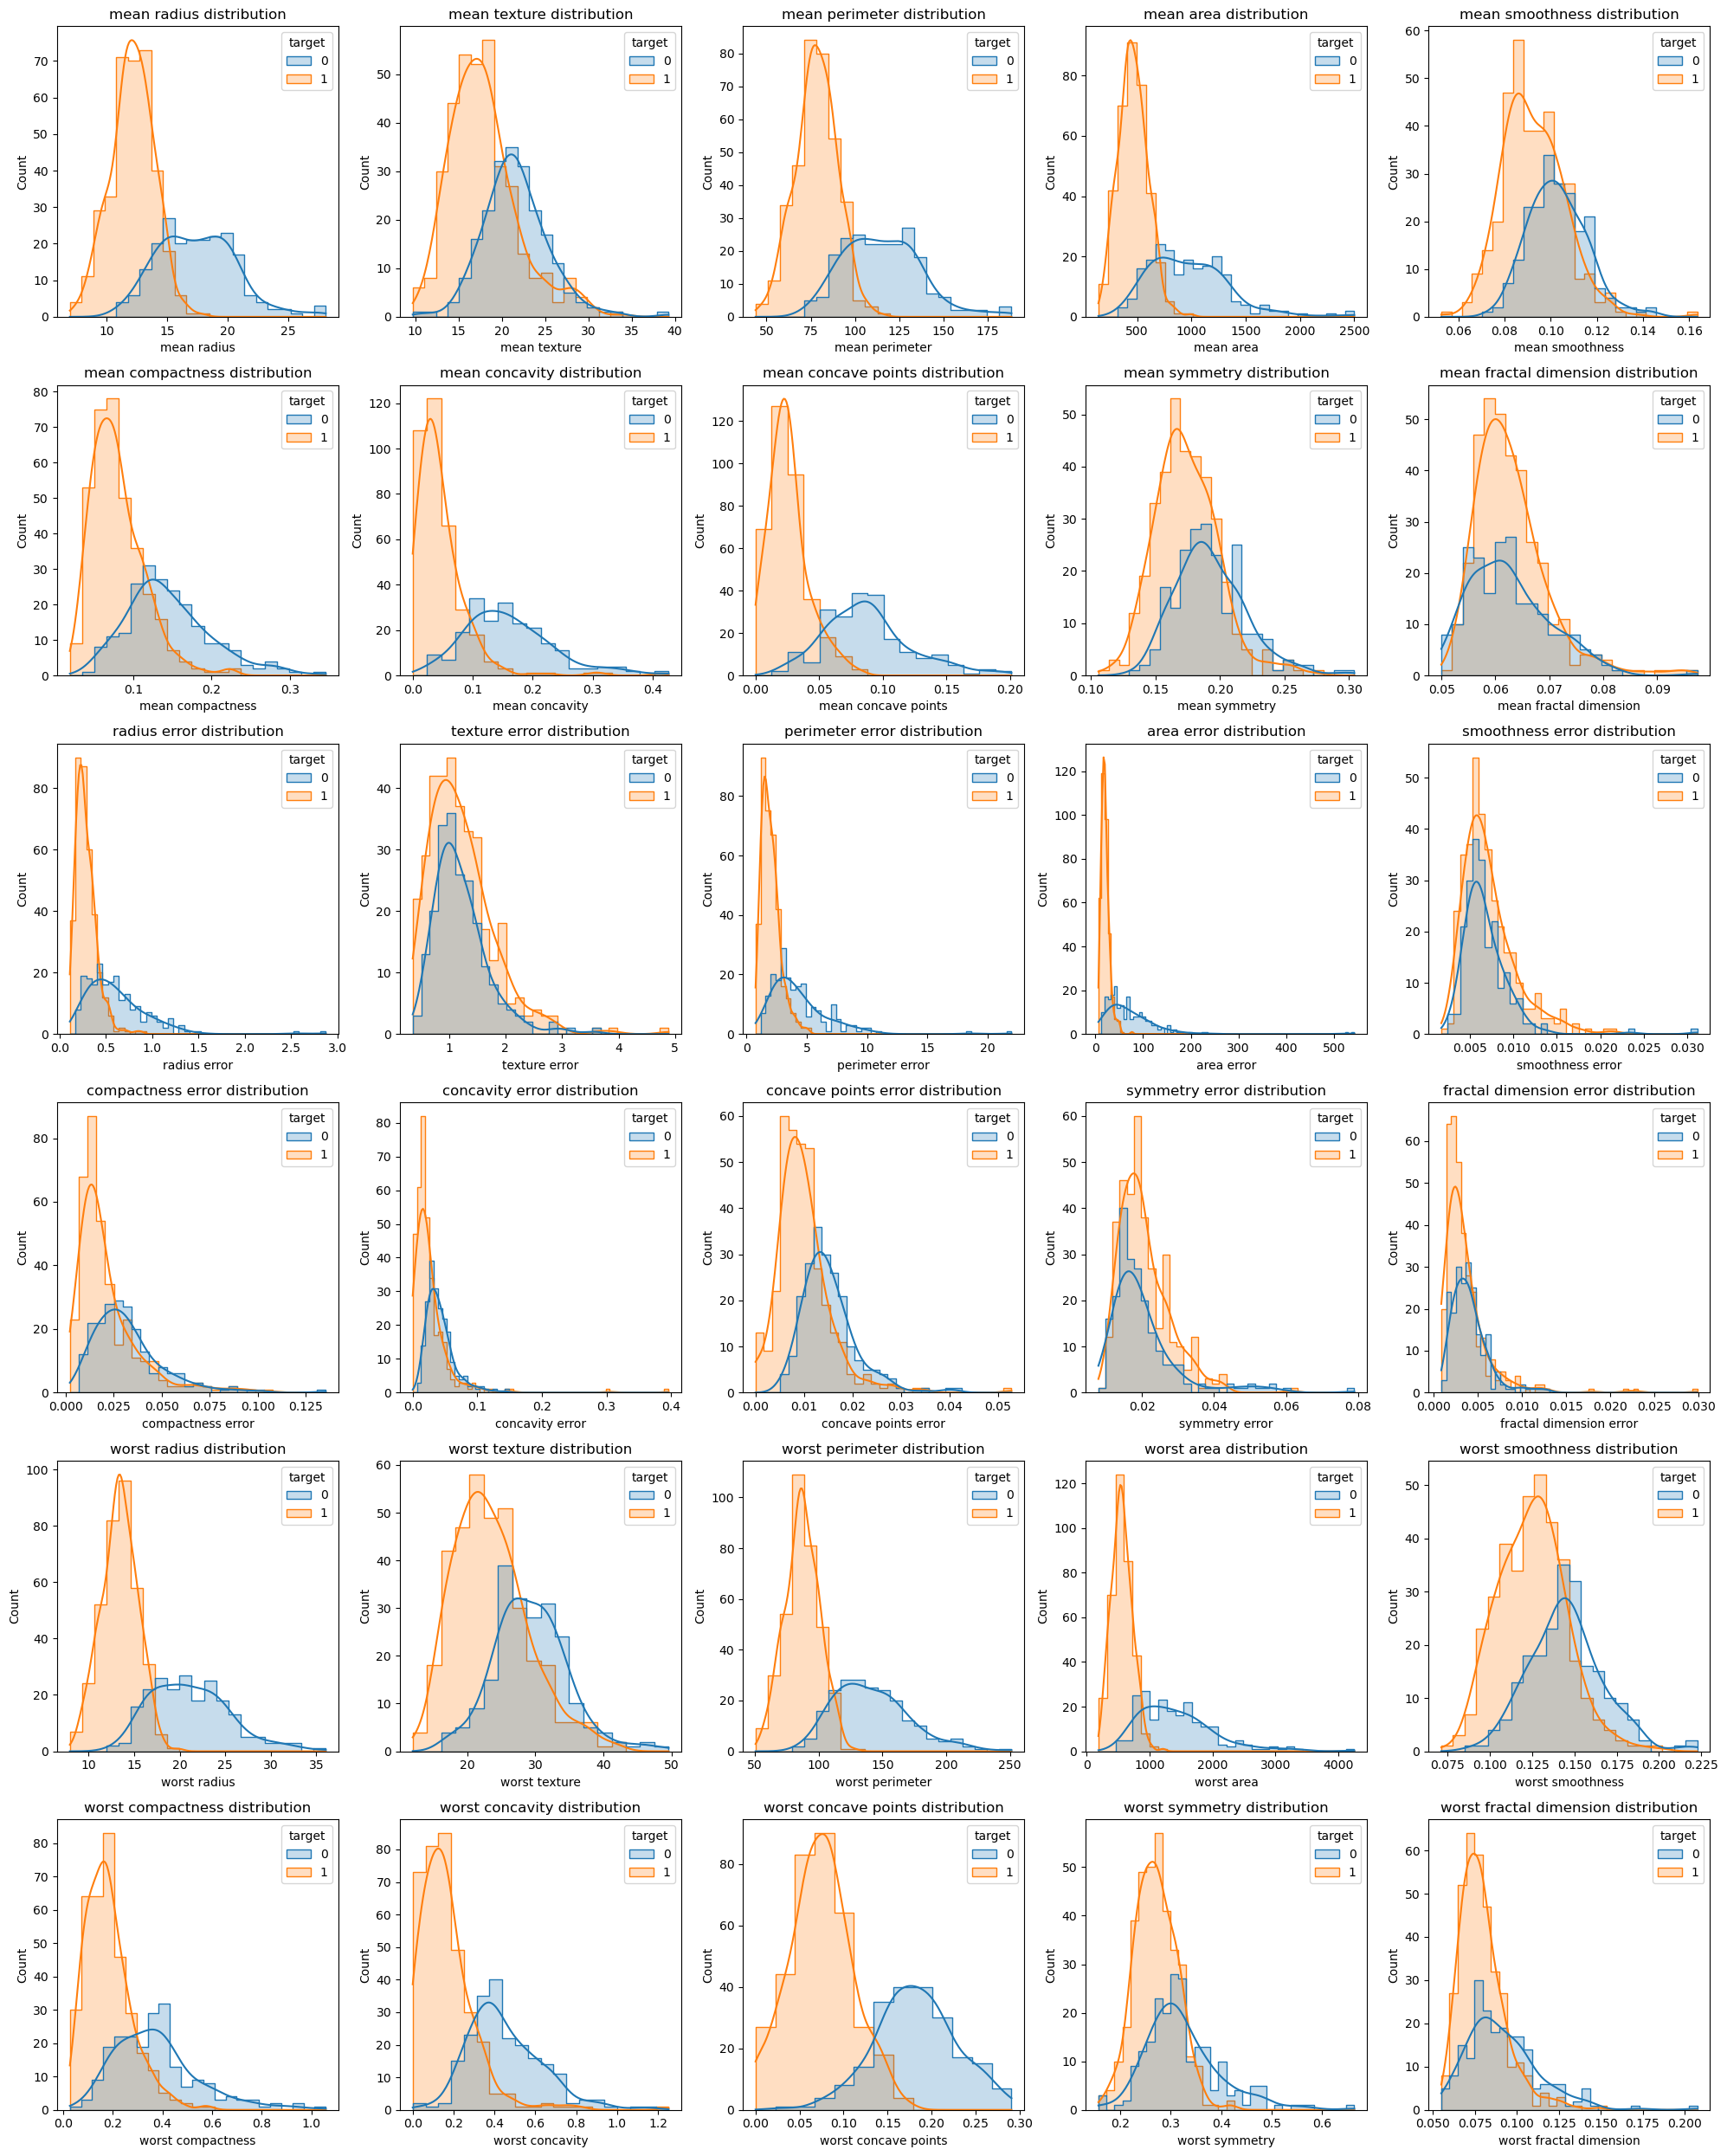

In [8]:
features = data.feature_names
plt.figure(figsize=(20, 25))

for i, feature in enumerate(features):
    plt.subplot(6, 5, i + 1)
    sns.histplot(data=df, x=feature, hue='target', kde=True, element="step")
    plt.title(f'{feature} distribution')

plt.tight_layout()
plt.show()

An initial inspection of the feature distributions reveals that several variables act as strong discriminators between malignant and benign cases. Specifically, **mean radius**, **mean perimeter**, **mean area**, **mean concavity** and **mean concave points**, along with their "worst" counterparts, exhibit the most significant separation between classes. The limited overlap observed in these distributions suggests that these features are highly informative for identifying malignant tumours.

At the same time, the distributions of radius, perimeter, and area appear very similar, indicating a high degree of multicollinearity. Since all three features capture related aspects of tumour size, they are likely to provide redundant information to the model. Additionally, concavity features display a separation pattern similar to concave points, further highlighting their relevance for the classification task.

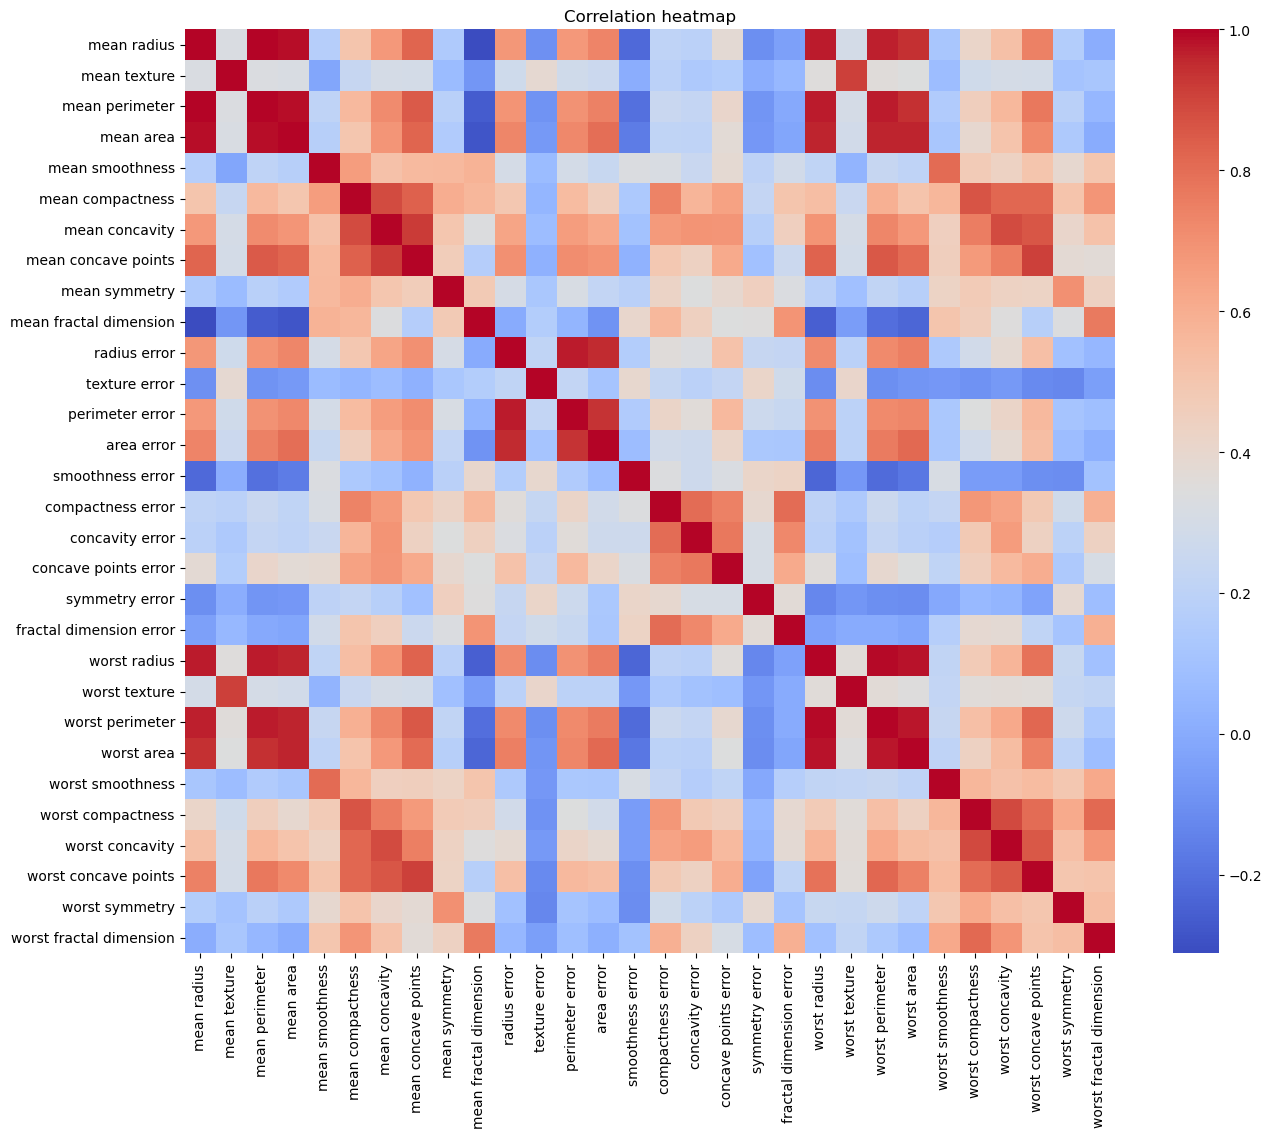

Top correlated pairs:
mean radius      mean perimeter         0.997855
worst radius     worst perimeter        0.993708
mean radius      mean area              0.987357
mean perimeter   mean area              0.986507
worst radius     worst area             0.984015
worst perimeter  worst area             0.977578
radius error     perimeter error        0.972794
mean perimeter   worst perimeter        0.970387
mean radius      worst radius           0.969539
mean perimeter   worst radius           0.969476
mean radius      worst perimeter        0.965137
mean area        worst radius           0.962746
                 worst area             0.959213
                 worst perimeter        0.959120
radius error     area error             0.951830
mean perimeter   worst area             0.941550
mean radius      worst area             0.941082
perimeter error  area error             0.937655
mean concavity   mean concave points    0.921391
mean texture     worst texture          0.91204

In [9]:
plt.figure(figsize=(15, 12))
corr_matrix = df.drop('target', axis=1).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

# Find the most correlated pairs of features
pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))
print("Top correlated pairs:")
print(pairs.head(20))

The correlation heatmap and the numerical ranking of top-correlated pairs strongly corroborate the visual patterns observed in the histograms. The extreme multicollinearity is mathematically confirmed by pairs such as **mean radius** and **mean perimeter** (r = 0.998), and **worst radius** and **worst perimeter** (r = 0.994), which directly explains why their respective histograms share nearly identical distributions. This alignment confirms that these features are geometrically redundant, as they all measure different aspects of tumor size. Beyond size, the high correlation between **mean concavity and mean concave points** (r = 0.921) confirms the overlapping distribution patterns seen for these shape-related variables. 

The data also reveals important relationships that were less obvious in the individual plots, such as the strong link between "mean" and "worst" measurements (e.g., **mean texture and worst texture** at r = 0.912), indicating that patients with high average values consistently exhibit high peak values as well. Furthermore, the high correlation between **radius error and perimeter error** (r = 0.973) suggests that the variance in measurement is also uniform across size-related metrics.

## Task 2: Preprocessing and feature analysis

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Split the data**

In [11]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [12]:
# We check the distribution of classes in the training and test sets to ensure they are balanced
print(f"Train: {len(X_train)} (Malignant: {sum(y_train==0)}, Benign: {sum(y_train==1)})")
print(f"Test: {len(X_test)} (Malignant: {sum(y_test==0)}, Benign: {sum(y_test==1)})")

Train: 455 (Malignant: 170, Benign: 285)
Test: 114 (Malignant: 42, Benign: 72)


**StandardScaler**

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # We fit the scaler only on the training set to avoid data leakage
X_test_scaled = scaler.transform(X_test) # We transform the test data using the fitted scaler
# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


**Correlation**

In [14]:
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # We use the upper triangle of the correlation matrix to avoid duplicate pairs and self-correlation

correlation_threshold = 0.95 # We use a correlation threshold of 0.95 to identify highly redundant predictors

high_corr_pairs = (
    upper
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"] > correlation_threshold
].sort_values(by="Correlation", ascending=False)

high_corr_pairs

,Feature 1,Feature 2,Correlation
1,mean radius,mean perimeter,0.997789
391,worst radius,worst perimeter,0.993478
2,mean radius,mean area,0.988886
57,mean perimeter,mean area,0.987834
392,worst radius,worst area,0.985890
407,worst perimeter,worst area,0.978738
76,mean perimeter,worst perimeter,0.970918
246,radius error,perimeter error,0.970870
19,mean radius,worst radius,0.970133
74,mean perimeter,worst radius,0.969674


In [15]:
features_to_drop = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

features_to_drop

['mean perimeter',
 'mean area',
 'perimeter error',
 'area error',
 'worst radius',
 'worst perimeter',
 'worst area']

In [16]:
X_train_reduced = X_train_scaled.drop(columns=features_to_drop)
X_test_reduced = X_test_scaled.drop(columns=features_to_drop)
print("Original number of features:", X_train.shape[1])
print("Reduced number of features after scaling:", X_train_reduced.shape[1])
print("Dropped features:", features_to_drop)

Original number of features: 30
Reduced number of features after scaling: 23
Dropped features: ['mean perimeter', 'mean area', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area']


Based on the correlation analysis, seven features were removed from the dataset: `mean perimeter`, `mean area`, `perimeter error`, `area error`, `worst radius`, `worst perimeter`, and `worst area`. These variables were not removed because they were irrelevant, but because they were highly redundant with other features already present in the dataset.

This decision is consistent with the results observed in Task 1. The histograms showed that several size-related variables, such as `mean radius`, `mean perimeter`, and `mean area`, had very similar distribution patterns and separated malignant and benign cases in a comparable way. This suggested that these features were capturing closely related information about tumour size.

The correlation heatmap confirmed very strong correlations between geometrically related variables, especially radius, perimeter, and area measurements, including their “worst” and error versions. This is expected because larger nuclei tend to have larger radii, perimeters, and areas, so keeping all these variables would introduce redundant information into the models. For this reason, the most correlated and redundant features were removed.

Overall, the feature reduction was based on both visual evidence from the histograms and the correlation analysis. Removing highly correlated features helps reduce multicollinearity and improves interpretability.